In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

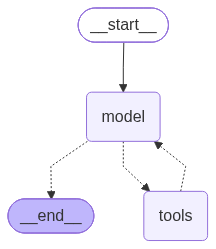

In [18]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

def get_weather(city:str)-> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."

model = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("GROQ_API_KEY")
)

agent=create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [20]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is the weather in Delhi?"}
    ]
})

In [21]:
response["messages"]

[HumanMessage(content='What is the weather in Delhi?', additional_kwargs={}, response_metadata={}, id='445a43d2-216e-4e09-9be1-a871666a1b9b'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks for weather in Delhi. We have a function get_weather. Need to call it.', 'tool_calls': [{'id': 'fc_f6ff3e12-bb52-43d9-bc0d-f3be374d02ba', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 136, 'total_tokens': 183, 'completion_time': 0.097916106, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.005507835, 'prompt_tokens_details': None, 'queue_time': 0.047753145, 'total_time': 0.103423941}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a016aa-6b6a-7523-9f58-f426856a7d7e-0', tool_calls=[{'

In [22]:
agent.invoke({"messages":"What is the weather in New York"})

{'messages': [HumanMessage(content='What is the weather in New York', additional_kwargs={}, response_metadata={}, id='745b44b3-7709-4c08-bc18-9f0a32b94485'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to fetch weather using function get_weather.', 'tool_calls': [{'id': 'fc_4c52af8b-4a09-4e1b-ae3e-3bcc9c7e67c7', 'function': {'arguments': '{"city":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 136, 'total_tokens': 175, 'completion_time': 0.08160205, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.026550533, 'prompt_tokens_details': None, 'queue_time': 0.405480172, 'total_time': 0.108152583}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a016ab-1482-71a3-959a-1d6587a1219e-0', tool_calls=[{'name': 'ge

In [23]:
response["messages"][-1].content

'The weather in Delhi is currently sunny.'

In [24]:
#my first agent
SYSTEM_PROMPT = """You are a Civic Sense Classifier.

# The user will provide a paragraph or multiple actions.

# Classify each action as either:

# * **Civic Sense**
# * **No Civic Sense**

# Return only the classifications in the same order as the user's points.

# Do not explain, repeat, or modify the actions.

# Example:
# Input:

# 1. Throwing garbage on the road
# 2. Helping an elderly person cross the road
# 3. Following traffic rules

# Output:

# 1. No Civic Sense
# 2. Civic Sense
# 3. Civic Sense
"""

In [29]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
model = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("GROQ_API_KEY"),
    max_tokens =200,
)

@tool lagane ke baad LangChain ise Tool object bana deta hai, jise agent use kar sakta hai.

So:

Normal function
      ->
    @tool
      ->
LangChain Tool
      ->
Agent can use it

In [ ]:
from langchain.tools import tool

@tool
def get_civic_rule(topic: str) -> str:
    """Get basic civic information about a given topic."""
    #Agent tools mein docstring important hoti hai Ye agent ko batati hai, Ye tool kis kaam ke liye hai?,
    # Agent ko tool choose karna ho, to ye description help karti hai.
    

    #Ye simply tumhara knowledge/data hai.
    rules = {
        "littering": "Do not throw waste in public places.",
        "traffic": "Follow traffic signals and road safety rules.",
        "parking": "Do not block footpaths or unauthorized areas.",
        "public_property": "Do not damage public property."
    }

    return rules.get(
        topic.lower(),#lowers input
        "No specific civic rule found."#default output
    )

In [31]:
agent=create_agent(
    model=model,
     tools=[get_civic_rule],
    system_prompt=SYSTEM_PROMPT,
)

In [35]:
content = """1. A person throws garbage on the road.
2. A person waits for the traffic signal to turn green.
3. Someone parks their vehicle on the footpath.
4. A person helps an elderly person cross the road.
5. Someone spits in a public place."""


response = agent.invoke({
    "messages": [
        {"role": "user", "content": content}
    ]
})
print(response["messages"][-1].content
)


1. No Civic Sense
2. Civic Sense
3. No Civic Sense
4. Civic Sense
5. No Civic Sense
